In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dense,
    Dropout,
    Flatten
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [10]:
# =========================================================
# STEP 1: PROVIDE SCALOGRAM IMAGE DATASET PATH
# =========================================================



dataset_path = r"/content/ScalogramImages.zip" # Reverted to original zip file path

In [15]:
import zipfile

extraction_path = '/content/extracted_images'
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"\nZip file extracted to: {extraction_path}")


Zip file extracted to: /content/extracted_images


In [16]:
# =========================================================
# STEP 2: LOAD IMAGE PATHS & LABELS
# =========================================================

image_paths = []
image_labels = []

In [17]:
# Assuming the zip extracts into a single top-level folder (e.g., ScalogramImages)
# directly under extraction_path, and class folders are inside that.

actual_image_root = None
# Find the first directory inside extraction_path, which should be the main dataset folder
for item in os.listdir(extraction_path):
    full_item_path = os.path.join(extraction_path, item)
    if os.path.isdir(full_item_path):
        actual_image_root = full_item_path
        break # Assuming there's only one main folder after extraction

image_paths = [] # Clear lists before repopulating, in case of re-run
image_labels = []

if actual_image_root is None:
    print(f"Error: Could not find the main image directory inside {extraction_path}")
else:
    # Now iterate through the actual class folders within this root
    for class_name in os.listdir(actual_image_root):
        class_path = os.path.join(actual_image_root, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(img_path)
                    image_labels.append(class_name) # class_name is now 'NSR', 'AFIB' etc.

print(f"\nFound {len(image_paths)} images with {len(set(image_labels))} classes.")


Found 164 images with 3 classes.


In [18]:
# =========================================================
# STEP 3: SPLIT DATASET
# =========================================================

train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.2,
    random_state=60,
    stratify=image_labels
)

print(f"\nTraining Images: {len(train_paths)}")
print(f"Testing Images : {len(test_paths)}")


Training Images: 131
Testing Images : 33


In [19]:
# =========================================================
# STEP 4: CREATE DATAFRAMES
# =========================================================

import pandas as pd

train_df = pd.DataFrame({
    'filename': train_paths,
    'class': train_labels
})

test_df = pd.DataFrame({
    'filename': test_paths,
    'class': test_labels
})

In [20]:
# =========================================================
# STEP 5: IMAGE GENERATORS
# =========================================================

image_size = (224, 224)
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 131 validated image filenames belonging to 3 classes.
Found 33 validated image filenames belonging to 3 classes.


In [21]:
# =========================================================
# STEP 6: DEFINE CNN ARCHITECTURE
# =========================================================

num_classes = len(set(image_labels))

model = Sequential([

    Conv2D(
        8,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(224,224,3)
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),


    Conv2D(
        16,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),


    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),


    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:

# =========================================================
# STEP 7: COMPILE MODEL
# =========================================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
# =========================================================
# STEP 8: TRAIN CNN MODEL
# =========================================================

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 900ms/step - accuracy: 0.4656 - loss: 11.6625 - val_accuracy: 0.6061 - val_loss: 1.0518
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6107 - loss: 1.3205 - val_accuracy: 0.7576 - val_loss: 1.0541
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6412 - loss: 0.7871 - val_accuracy: 0.6364 - val_loss: 1.0265
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 813ms/step - accuracy: 0.6718 - loss: 0.7038 - val_accuracy: 0.4242 - val_loss: 1.0275
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 996ms/step - accuracy: 0.6718 - loss: 0.5762 - val_accuracy: 0.2121 - val_loss: 1.2892
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 878ms/step - accuracy: 0.6947 - loss: 0.5434 - val_accuracy: 0.2121 - val_loss: 1.6784
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 811ms/step - accuracy: 0.7557 - loss: 0.4988 - val_accuracy: 0.2121 - val_loss: 2.1001
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 982ms/step - accuracy: 0.8015 - loss: 0.4769 - val_accuracy: 0.2121 - val_loss: 2

In [24]:
# =========================================================
# STEP 9: TRAINING & TESTING ACCURACY
# =========================================================

train_accuracy = history.history['accuracy'][-1] * 100

test_accuracy = history.history['val_accuracy'][-1] * 100

print(f"\nFinal Training Accuracy = {train_accuracy:.2f}%")
print(f"Final Testing Accuracy  = {test_accuracy:.2f}%")



Final Training Accuracy = 87.79%
Final Testing Accuracy  = 100.00%


In [25]:
# =========================================================
# STEP 10: TEST CNN MODEL
# =========================================================

predictions = model.predict(test_generator)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = test_generator.classes


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step


In [26]:
# =========================================================
# STEP 11: FINAL CLASSIFICATION ACCURACY
# =========================================================

final_accuracy = accuracy_score(
    true_labels,
    predicted_labels
) * 100

print(f"\nCNN Classification Accuracy = {final_accuracy:.2f}%")


CNN Classification Accuracy = 100.00%


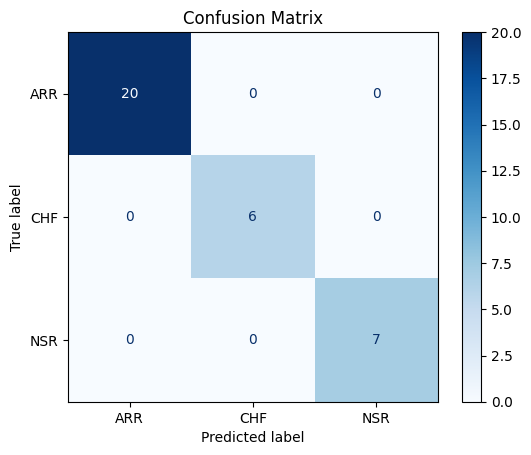

In [27]:
# =========================================================
# STEP 12: CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(test_generator.class_indices.keys())
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix')

plt.show()


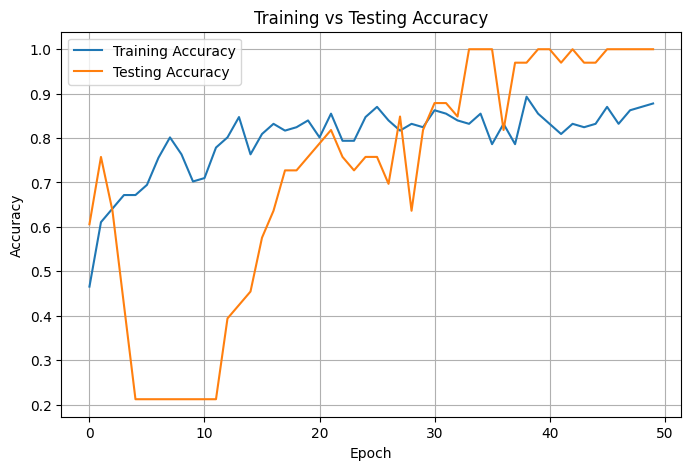

In [28]:
# =========================================================
# STEP 13: ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Testing Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Training vs Testing Accuracy')

plt.legend()

plt.grid(True)

plt.show()


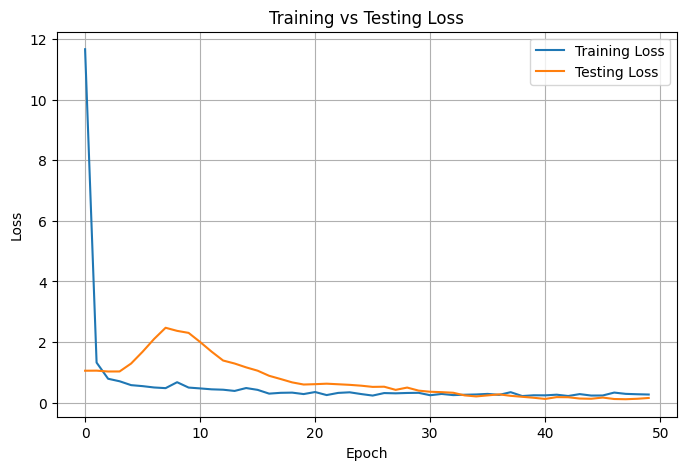

In [29]:
# =========================================================
# STEP 14: LOSS GRAPH
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Testing Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training vs Testing Loss')

plt.legend()

plt.grid(True)

plt.show()

In [30]:

# =========================================================
# STEP 15: SAVE MODEL
# =========================================================

model.save('ECG_CNN_Model.h5')

print("\nModel Saved Successfully!")


Model Saved Successfully!
